In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
import helper_functions as hf
import chainedMorpher as qrnn
import scipy
import sklearn.datasets as datasets
import os
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
device = torch.device('cuda:0')
from tqdm import tqdm
import h5py

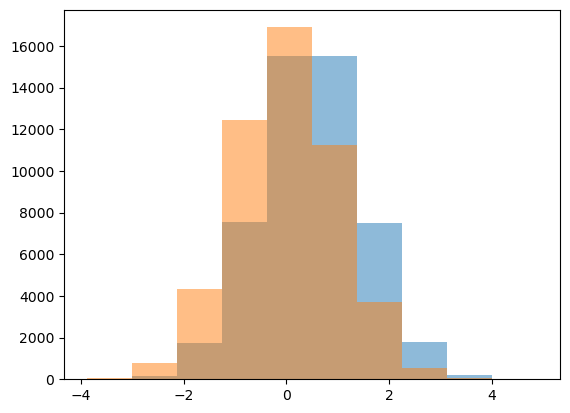

In [4]:
from torch.utils.data import Dataset

class DataSet(Dataset):
    def __init__(self, samples, labels):
        super(DataSet, self).__init__()
        self.labels  = labels
        self.samples = samples
        if len(samples) != len(labels):
            raise ValueError(
                f"should have the same number of samples({len(samples)}) as there are labels({len(labels)})")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        y = self.labels[index]
        x = self.samples[index]
        return x, y

def makeDataSet(iN=50000,iDim=2):
    v1=torch.randn(iN,iDim)
    v2=torch.randn(iN,iDim)
    v1[:,1] += 0.5
    _,bins,_=plt.hist(v1[:,1].cpu().numpy(),alpha=0.5)
    plt.hist(v2[:,1].cpu().numpy(),bins=bins,alpha=0.5)
    plt.show()
    tot=torch.cat([v1,v2])
    siglabel=torch.ones(len(v1))
    bkglabel=torch.zeros(len(v2))
    label=torch.cat((siglabel,bkglabel))
    data=DataSet(samples=tot,labels=label)
    return data,tot.cpu().numpy(),label
data,_,_=makeDataSet()

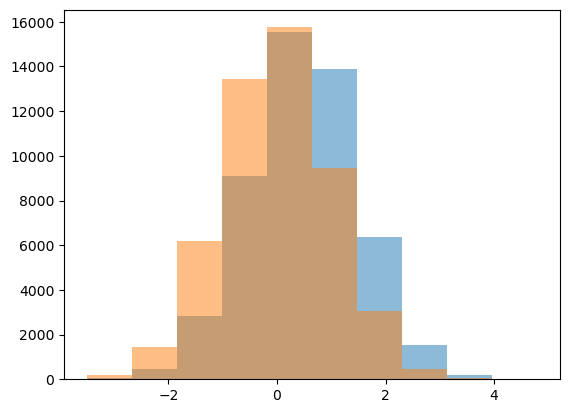

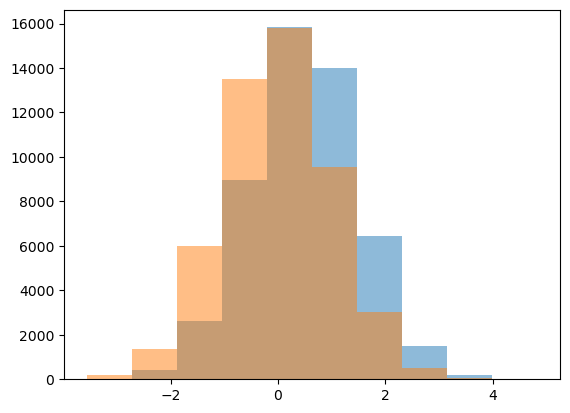

In [5]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3.2,"hidden_features":150,
             "num_layers":1,"num_bins":50,"num_blocks_per_layer":1,"tails":"linear",
            "dropout":0.0,"residual":True}
fitvars=["a","b"]
rangeScale = 3
variables = fitvars
alldata_train,train_in,labeltrain_in=makeDataSet()
alldata_test,test_in,label_in  =makeDataSet()
mc_train  =train_in[0:50000]
mc_test   =test_in[0:50000]
data_train=train_in[50000::]
data_test =test_in [50000::]

trainer = qrnn.chainedNFTrainer("phil_gaussians",mc_train,mc_test,data_train,data_test,fitvars,control=[],
                                NF_kwargs=NF_kwargs,rangeScale=rangeScale,separateScale=False)

Training flow bkgFlow_step0_a


Loss: 1.0582455891370772, p = 837: 100%|██████████| 1953/1953 [00:25<00:00, 77.31it/s]


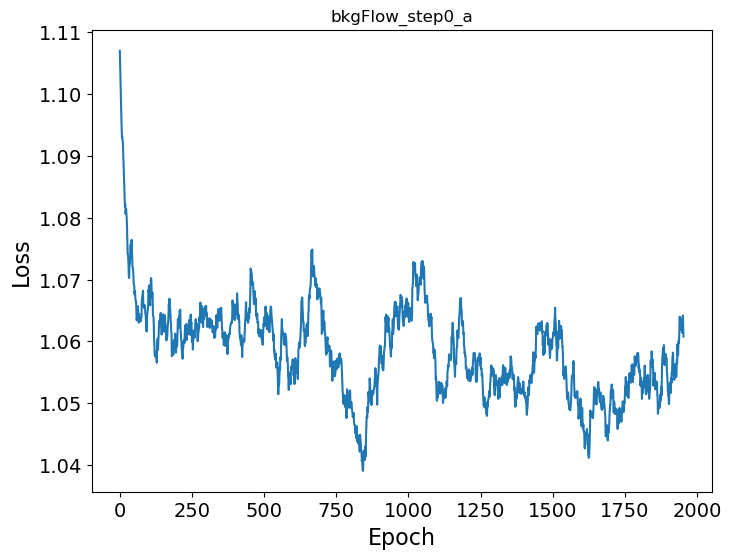

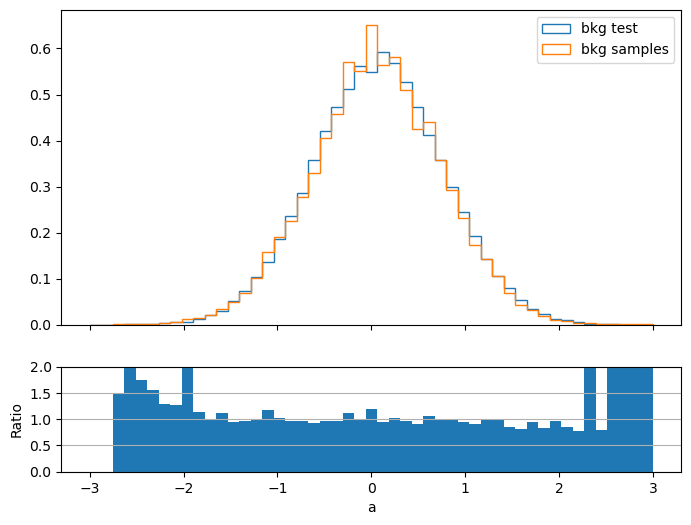

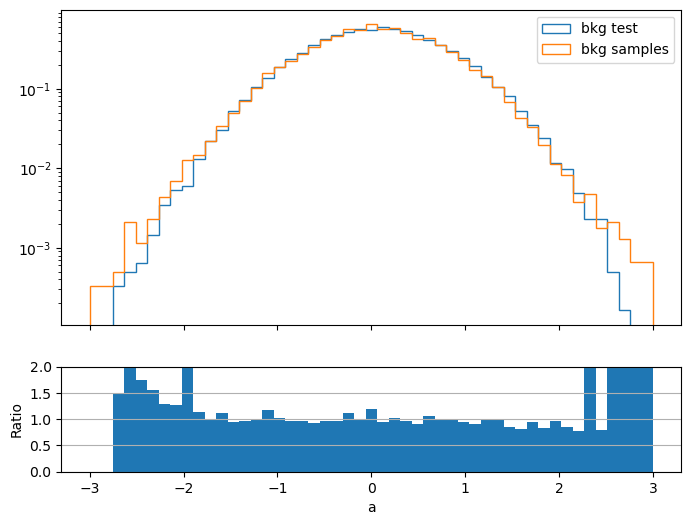

In [6]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3.2,"hidden_features":150,
             "num_layers":1,"num_bins":50,"num_blocks_per_layer":1,"tails":"linear",
            "dropout":0.0,"residual":True}
trainer.NF_kwargs = NF_kwargs
bs = 128
n_epoch = 5
n_iter = n_epoch*mc_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=5e-4,bs=bs)
trainer.plotDensity(bkg=True,ylim=[0,2])